# Diabetes Prediction

This project develops a machine learning model to predict whether a person is likely to have diabetes.

In [30]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [31]:
#loading the dataset
df = pd.read_csv('diabetes.csv')

## Exploring the Dataset

The dataset is examined to understand its structure, distributions, and data quality before any modelling begins.

In [3]:
# Returns number of rows and columns of the dataset
df.shape

(2000, 9)

In [4]:
# Returns an array of all of the column headers 
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [5]:
# Returns different datatypes for each columns (float, int, string, bool, etc.)
df.dtypes

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

In [6]:
# Returns the first x number of rows when head(num). Without a number it returns 5
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,2,138,62,35,0,33.6,0.127,47,1
1,0,84,82,31,125,38.2,0.233,23,0
2,0,145,0,0,0,44.2,0.630,31,1
3,0,135,68,42,250,42.3,0.365,24,1
4,1,139,62,41,480,40.7,0.536,21,0


In [7]:
#Returns the last x number of rows when tail(num). Without a number it returns 5
df.tail()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
1995,2,75,64,24,55,29.7,0.370,33,0
1996,8,179,72,42,130,32.7,0.719,36,1
1997,6,85,78,0,0,31.2,0.382,42,0
1998,0,129,110,46,130,67.1,0.319,26,1
1999,2,81,72,15,76,30.1,0.547,25,0


In [8]:
# Returns the number of non-null values in each column, as well as the datatype of each column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               2000 non-null   int64  
 1   Glucose                   2000 non-null   int64  
 2   BloodPressure             2000 non-null   int64  
 3   SkinThickness             2000 non-null   int64  
 4   Insulin                   2000 non-null   int64  
 5   BMI                       2000 non-null   float64
 6   DiabetesPedigreeFunction  2000 non-null   float64
 7   Age                       2000 non-null   int64  
 8   Outcome                   2000 non-null   int64  
dtypes: float64(2), int64(7)
memory usage: 140.8 KB


In [9]:
# Returns the basic statistical details of the dataset such as count, mean, std, min, 25%, 50%, 75%, and max for each column
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,3.703500,121.182500,69.145500,20.935000,80.254000,32.193000,0.470930,33.090500,0.342000
std,3.306063,32.068636,19.188315,16.103243,111.180534,8.149901,0.323553,11.786423,0.474498
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,63.500000,0.000000,0.000000,27.375000,0.244000,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,40.000000,32.300000,0.376000,29.000000,0.000000
75%,6.000000,141.000000,80.000000,32.000000,130.000000,36.800000,0.624000,40.000000,1.000000
max,17.000000,199.000000,122.000000,110.000000,744.000000,80.600000,2.420000,81.000000,1.000000


In [10]:
# Transpose of the describe() function to make it easier to read
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Pregnancies,2000.0,3.70350,3.306063,0.000,1.000,3.000,6.000,17.00
Glucose,2000.0,121.18250,32.068636,0.000,99.000,117.000,141.000,199.00
BloodPressure,2000.0,69.14550,19.188315,0.000,63.500,72.000,80.000,122.00
SkinThickness,2000.0,20.93500,16.103243,0.000,0.000,23.000,32.000,110.00
Insulin,2000.0,80.25400,111.180534,0.000,0.000,40.000,130.000,744.00
BMI,2000.0,32.19300,8.149901,0.000,27.375,32.300,36.800,80.60
DiabetesPedigreeFunction,2000.0,0.47093,0.323553,0.078,0.244,0.376,0.624,2.42
Age,2000.0,33.09050,11.786423,21.000,24.000,29.000,40.000,81.00
Outcome,2000.0,0.34200,0.474498,0.000,0.000,0.000,1.000,1.00


In [32]:
# Create a working copy and convert physiologically impossible 0 values to NaN
df_copy = df.copy(deep=True)
cols_with_invalid_zero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df_copy[cols_with_invalid_zero] = df_copy[cols_with_invalid_zero].replace(0, np.nan)

# Check missing values created after conversion
df_copy.isnull().sum()

Pregnancies                   0
Glucose                      13
BloodPressure                90
SkinThickness               573
Insulin                     956
BMI                          28
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

In [11]:
# Returns the number of unique values in each column
df.nunique()

Pregnancies                  17
Glucose                     136
BloodPressure                47
SkinThickness                53
Insulin                     182
BMI                         247
DiabetesPedigreeFunction    505
Age                          52
Outcome                       2
dtype: int64

In [12]:
#Returns empty cells in the dataset
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [33]:
# Rename DiabetesPedigreeFunction to DPF in both dataframes (keep names consistent)
df.rename(columns={"DiabetesPedigreeFunction": "DPF"}, inplace=True)
df_copy.rename(columns={"DiabetesPedigreeFunction": "DPF"}, inplace=True)

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DPF,Age,Outcome
0,2,138,62,35,0,33.6,0.127,47,1
1,0,84,82,31,125,38.2,0.233,23,0
2,0,145,0,0,0,44.2,0.630,31,1
3,0,135,68,42,250,42.3,0.365,24,1
4,1,139,62,41,480,40.7,0.536,21,0


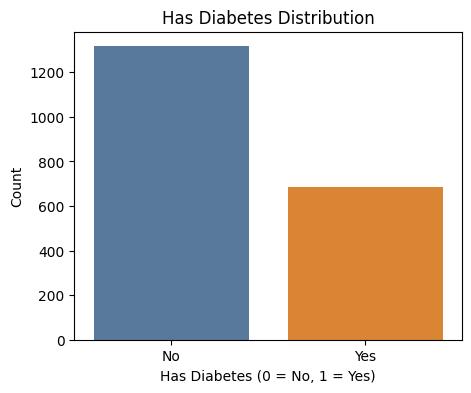

In [33]:
# Plotting the distribution of the target variable (Outcome)
plt.figure(figsize=(5, 4))
ax = sns.countplot(
    x='Outcome',
    data=df,
    hue='Outcome',
    palette={0: '#4C78A8', 1: '#F58518'},
    legend=False,
    order=[0, 1],
)
plt.title('Has Diabetes Distribution')
plt.xlabel('Has Diabetes (0 = No, 1 = Yes)')
plt.ylabel('Count')
ax.set_xticks([0, 1])
ax.set_xticklabels(['No', 'Yes'])
plt.show()

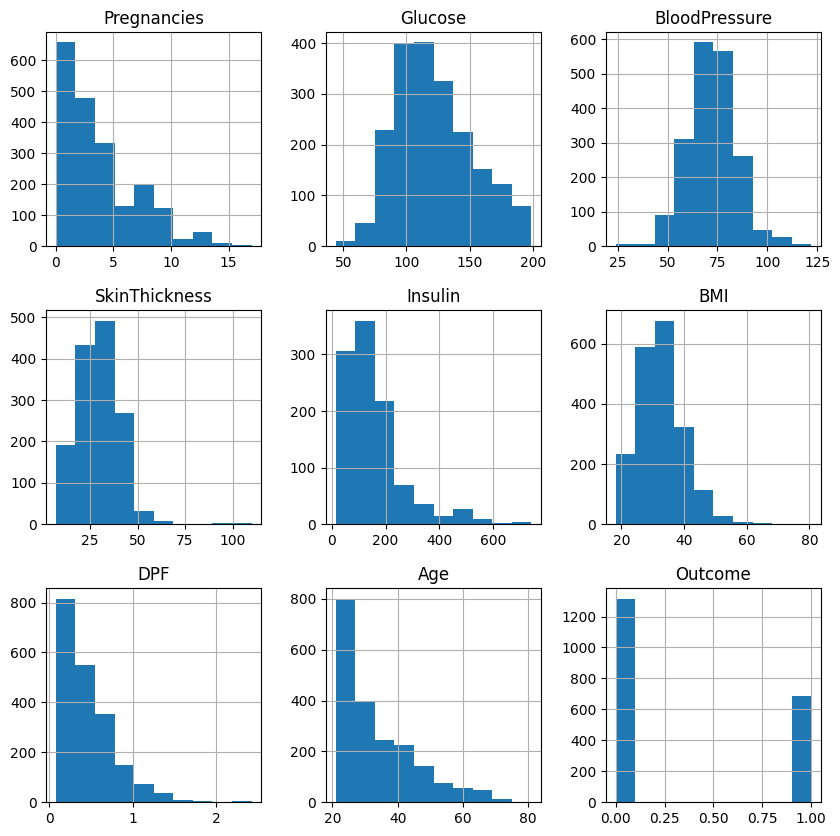

In [17]:
# Exploring the data distribution before replacing NaN values
p = df_copy.hist(figsize=(10, 10))

In [34]:
# Fill missing values with simple rules
df_copy['Glucose'] = df_copy['Glucose'].fillna(df_copy['Glucose'].mean())
df_copy['BloodPressure'] = df_copy['BloodPressure'].fillna(df_copy['BloodPressure'].mean())
df_copy['SkinThickness'] = df_copy['SkinThickness'].fillna(df_copy['SkinThickness'].median())
df_copy['Insulin'] = df_copy['Insulin'].fillna(df_copy['Insulin'].median())
df_copy['BMI'] = df_copy['BMI'].fillna(df_copy['BMI'].median())
df_copy['DPF'] = df_copy['DPF'].fillna(df_copy['DPF'].median())

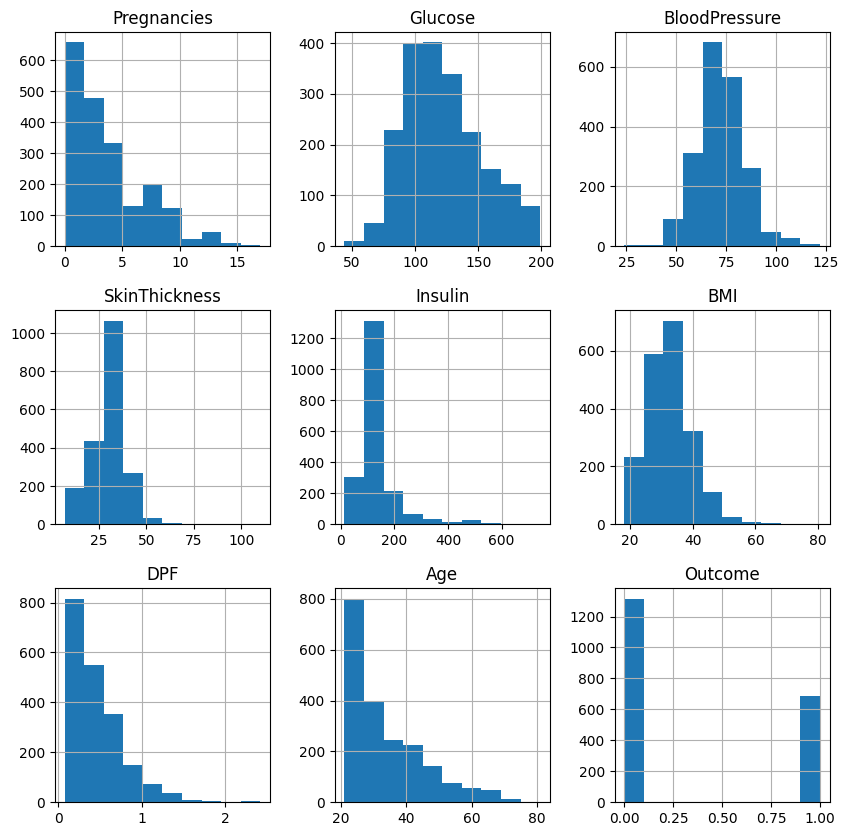

In [19]:
#Plotting the distribution after replacing NaN values
p = df_copy.hist(figsize=(10, 10))

In [6]:
#Checking for any remaining NaN values after imputation
df_copy.isnull().sum()

Pregnancies      0
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
DPF              0
Age              0
Outcome          0
dtype: int64

## Building Models

In this section, the workflow is:
1. Prepare features (`X`) and target (`y`).
2. Compare baseline classification models.
3. Select the best model using test-set accuracy.
4. Train a final model for evaluation and prediction.

In [35]:
# Function to compare baseline models
def find_best_model(X, y):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    models = {
        'Logistic Regression': make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)),
        'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    }

    scores = []
    for model_name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        test_acc = accuracy_score(y_test, y_pred)
        scores.append([model_name, round(test_acc, 4)])

    results_df = pd.DataFrame(scores, columns=['model', 'test_accuracy'])
    results_df = results_df.sort_values(by='test_accuracy', ascending=False).reset_index(drop=True)
    return results_df

In [36]:
# Choose which cleaned dataset to use for modeling
model_df = df_copy if 'df_copy' in globals() else df

# Split the dataframe into input features (X) and target label (y)
# X = all columns except Outcome
# y = the Outcome column we want to predict
X = model_df.drop('Outcome', axis=1)
y = model_df['Outcome']

# Run the model comparison function
# This function trains multiple models and returns their accuracy in a table
best_models_df = find_best_model(X, y)

# Display the results table
best_models_df

,model,test_accuracy
0,Random Forest,0.9825
1,Logistic Regression,0.7975


Random Forest produced the strongest performance in this comparison, so it is selected as the final model.

In [18]:
# Cross-validation accuracy for Random Forest
rf_cv_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Use X and y prepared in the previous cell
scores = cross_val_score(rf_cv_model, X, y, cv=5, scoring='accuracy')

print('Fold scores:', [round(float(s), 4) for s in scores])
print('Average Accuracy: {:.2f}%'.format(float(scores.mean() * 100)))

Fold scores: [0.9975, 1.0, 1.0, 0.975, 1.0]
Average Accuracy: 99.45%


In [37]:
# Create and train the final Random Forest model
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

## Model Evaluation

This section evaluates model performance on:
1. **Test set** (generalization to unseen data)
2. **Train set** (overfitting check)

Metrics used: confusion matrix, accuracy, and classification report.

In [20]:
#Creating a confusion matrix to understand the performance of the model
y_pred = rf_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
cm

array([[259,   4],
       [  3, 134]])

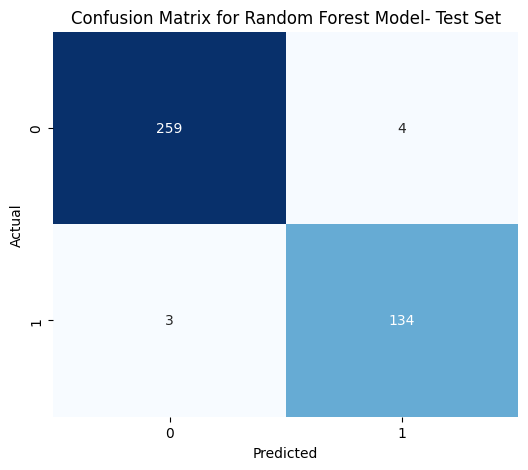

In [26]:
#Plotting the confusion matrix
plt.figure(figsize=(6, 5))
p = sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix for Random Forest Model- Test Set')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()
    

In [21]:
#Accuracy score for the test set
accuracy = accuracy_score(y_test, y_pred)
print('Test Set Accuracy: {:.2f}%'.format(accuracy * 100))

Test Set Accuracy: 98.25%


In [12]:
# Classification Report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.98      0.99       263
           1       0.97      0.98      0.97       137

    accuracy                           0.98       400
   macro avg       0.98      0.98      0.98       400
weighted avg       0.98      0.98      0.98       400



In [13]:
# Creating a confusion matrix for training set
y_train_pred = rf_model.predict(X_train)
cm = confusion_matrix(y_train, y_train_pred)

In [14]:
# Compare train vs test performance to quickly check overfitting

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_pred)

print('Train Set Accuracy: {:.2f}%'.format(train_acc * 100))
print('Test Set Accuracy: {:.2f}%'.format(test_acc * 100))
print('Accuracy Gap (Train - Test): {:.2f}%'.format((train_acc - test_acc) * 100))

Train Set Accuracy: 100.00%
Test Set Accuracy: 98.25%
Accuracy Gap (Train - Test): 1.75%


### Train Set Check

This check compares train and test performance.
A large train-test performance gap indicates potential overfitting.

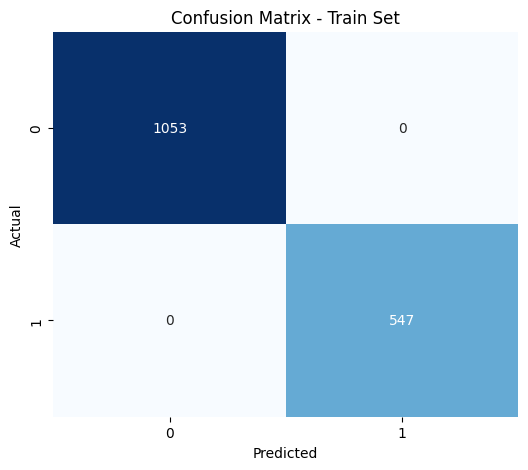

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1053
           1       1.00      1.00      1.00       547

    accuracy                           1.00      1600
   macro avg       1.00      1.00      1.00      1600
weighted avg       1.00      1.00      1.00      1600



In [29]:
# Train-set confusion matrix and classification report
y_train_eval_pred = rf_model.predict(X_train)
cm_train_eval = confusion_matrix(y_train, y_train_eval_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_train_eval, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix - Train Set')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print(classification_report(y_train, y_train_eval_pred))

## Next Steps: Extended Evaluation and Interpretation

After baseline evaluation, the workflow is extended with:
1. ROC curve and AUC score
2. Feature-importance analysis from Random Forest
3. Sample patient-level predictions

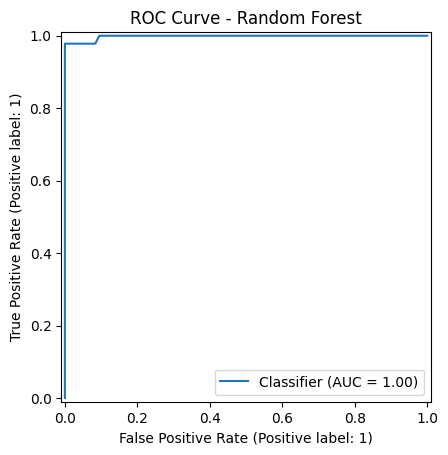

ROC-AUC Score: 0.9980


In [16]:
# ROC curve and AUC score
from sklearn.metrics import roc_auc_score, RocCurveDisplay

y_proba = rf_model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_proba)

RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title('ROC Curve - Random Forest')
plt.show()
print('ROC-AUC Score: {:.4f}'.format(auc))

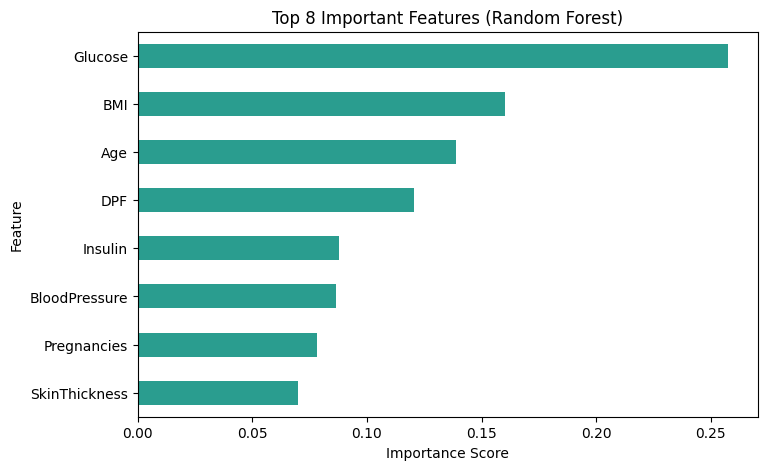

Glucose          0.257607
BMI              0.160004
Age              0.138891
DPF              0.120704
Insulin          0.087902
BloodPressure    0.086433
Pregnancies      0.078343
SkinThickness    0.070116
dtype: float64

In [17]:
# Top feature importance
feature_importance = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
feature_importance.head(8).sort_values().plot(kind='barh', color='#2A9D8F')
plt.title('Top 8 Important Features (Random Forest)')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()

feature_importance.head(8)

In [22]:
# Predict for one new patient (example values)
new_patient = pd.DataFrame([{
    'Pregnancies': 2,
    'Glucose': 130,
    'BloodPressure': 72,
    'SkinThickness': 28,
    'Insulin': 120,
    'BMI': 31.5,
    'DPF': 0.35,
    'Age': 33,
}])

pred_label = rf_model.predict(new_patient)[0]
pred_prob = rf_model.predict_proba(new_patient)[0, 1]

print('Prediction (0 = No Diabetes, 1 = Diabetes):', int(pred_label))
print('Probability of Diabetes: {:.2f}%'.format(pred_prob * 100))

Prediction (0 = No Diabetes, 1 = Diabetes): 1
Probability of Diabetes: 51.00%


## Predictions

This section applies the trained model to sample patient profiles and reports prediction probabilities.

In [38]:
# Function for prediction
# Input order: Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DPF, Age
def predict_diabetes(Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DPF, Age):
    x = pd.DataFrame([{
        'Pregnancies': int(Pregnancies),
        'Glucose': float(Glucose),
        'BloodPressure': float(BloodPressure),
        'SkinThickness': float(SkinThickness),
        'Insulin': float(Insulin),
        'BMI': float(BMI),
        'DPF': float(DPF),
        'Age': int(Age)
    }])

    prediction = int(rf_model.predict(x)[0])
    probability = float(rf_model.predict_proba(x)[0, 1])
    return prediction, probability

In [39]:
# Prediction 1
pred, prob = predict_diabetes(2, 81, 72, 15, 76, 30.1, 0.547, 25)
if pred == 1:
    print('Model prediction: Diabetes detected (class 1).')
else:
    print('Model prediction: No diabetes detected (class 0).')
print('Predicted probability of diabetes: {:.2f}%'.format(prob * 100))

Model prediction: No diabetes detected (class 0).
Predicted probability of diabetes: 0.00%


In [40]:
# Prediction 2
pred, prob = predict_diabetes(1, 117, 88, 24, 145, 34.5, 0.403, 40)
if pred == 1:
    print('Model prediction: Diabetes detected (class 1).')
else:
    print('Model prediction: No diabetes detected (class 0).')
print('Predicted probability of diabetes: {:.2f}%'.format(prob * 100))

Model prediction: Diabetes detected (class 1).
Predicted probability of diabetes: 98.00%


In [41]:
# Prediction 3
pred, prob = predict_diabetes(5, 120, 92, 10, 81, 26.1, 0.551, 67)
if pred == 1:
    print('Model prediction: Diabetes detected (class 1).')
else:
    print('Model prediction: No diabetes detected (class 0).')
print('Predicted probability of diabetes: {:.2f}%'.format(prob * 100))

Model prediction: No diabetes detected (class 0).
Predicted probability of diabetes: 5.00%
